# Advanced Machine Learning — D2.2 Project Documentation

**Forecasting daily IFR flight movements at Palma de Mallorca Airport (LEPA)**  
**Authors:** Xabier Villa López & Illart Dekhli Moreno

This notebook is the executable evidence for D2.2. It applies the required time-series forecasting techniques to the Eurocontrol airport-traffic dataset selected in the previous delivery: time-series analysis and decomposition, ARMA, ARIMA, SARIMA, AutoARIMA, a Transformer-based architecture, baseline comparison, results discussion and lessons learned.

> **Before submission:** run the notebook from top to bottom and save it with all outputs visible. The rubric requires a fully executable notebook and console outputs. Also replace the placeholder below with the public Google Drive link to the dataset folder.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import sys
import subprocess
from time import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting defaults
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Directory used by the document to import generated figures.
FIG_DIR = "dv22_figures"
os.makedirs(FIG_DIR, exist_ok=True)


## 1. Data Loading

The data comes from the Eurocontrol Aviation Intelligence Portal. The portal publishes daily airport traffic one CSV per year. We concatenate all yearly files, filter the selected airport (`LEPA`, Palma de Mallorca) and use total daily IFR movements (`FLT_TOT_IFR_2`) as the forecasting target.

**Dataset public access:** paste the shared Google Drive folder link here before submission:  
`[INSERT PUBLIC GOOGLE DRIVE DATASET LINK HERE]`

In [2]:
# Folder containing the yearly Eurocontrol CSVs (one file per year).
# In Colab, mount Google Drive and point DATA_DIR to the shared folder.
DATA_DIR = "eurocontrol_data"
FILE_PATTERN = "*.csv"

DATE_COL = "FLT_DATE"
ICAO_COL = "APT_ICAO"
TOTAL_IFR_COL = "FLT_TOT_IFR_2"   # total daily IFR movements (departures + arrivals)

files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_PATTERN)))
assert len(files) > 0, (
    f"No files matched {DATA_DIR}/{FILE_PATTERN}. "
    "Upload the Eurocontrol yearly CSVs to DATA_DIR or update DATA_DIR."
)

print(f"Found {len(files)} yearly file(s):")
for f in files:
    print(f"  {f}")

parts = []
for f in files:
    part = pd.read_csv(f)
    missing_cols = {DATE_COL, ICAO_COL, TOTAL_IFR_COL} - set(part.columns)
    assert not missing_cols, f"{f} is missing columns: {missing_cols}"
    part = part[part[ICAO_COL] == "LEPA"]
    parts.append(part)

df_raw = pd.concat(parts, ignore_index=True)
print(f"\nRows for LEPA across all files: {len(df_raw):,}")
print("Columns:", list(df_raw.columns))
df_raw.head()

Found 11 yearly file(s):
  eurocontrol_data\airport_traffic_2016.csv
  eurocontrol_data\airport_traffic_2017.csv
  eurocontrol_data\airport_traffic_2018.csv
  eurocontrol_data\airport_traffic_2019.csv
  eurocontrol_data\airport_traffic_2020.csv
  eurocontrol_data\airport_traffic_2021.csv
  eurocontrol_data\airport_traffic_2022.csv
  eurocontrol_data\airport_traffic_2023.csv
  eurocontrol_data\airport_traffic_2024.csv
  eurocontrol_data\airport_traffic_2025.csv
  eurocontrol_data\airport_traffic_2026.csv

Rows for LEPA across all files: 3,773
Columns: ['YEAR', 'MONTH_NUM', 'MONTH_MON', 'FLT_DATE', 'APT_ICAO', 'APT_NAME', 'STATE_NAME', 'FLT_DEP_1', 'FLT_ARR_1', 'FLT_TOT_1', 'FLT_DEP_IFR_2', 'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2']


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
0,2016,1,JAN,2016-01-01,LEPA,Palma de Mallorca,Spain,102,104,206,102.0,104.0,206.0
1,2016,1,JAN,2016-01-02,LEPA,Palma de Mallorca,Spain,148,142,290,148.0,141.0,289.0
2,2016,1,JAN,2016-01-03,LEPA,Palma de Mallorca,Spain,156,154,310,154.0,155.0,309.0
3,2016,1,JAN,2016-01-04,LEPA,Palma de Mallorca,Spain,120,121,241,120.0,120.0,240.0
4,2016,1,JAN,2016-01-05,LEPA,Palma de Mallorca,Spain,103,103,206,103.0,104.0,207.0


In [3]:
# Shape the dataframe for modelling.
df = (
    df_raw
    .loc[:, [DATE_COL, TOTAL_IFR_COL]]
    .copy()
)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.set_index(DATE_COL).sort_index()
df = df.rename(columns={TOTAL_IFR_COL: "flights"})

# Drop accidental duplicate dates caused by overlapping yearly files.
df = df[~df.index.duplicated(keep="first")]

# Reindex to a continuous daily frequency to expose missing dates.
full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
df = df.reindex(full_index)
df.index.name = "date"

print(f"Date range before cleaning: {df.index.min().date()} -> {df.index.max().date()}")
print(f"Total calendar days:        {len(df):,}")
print(f"Missing daily values:       {int(df['flights'].isna().sum())}")
df.head()

Date range before cleaning: 2016-01-01 -> 2026-04-30
Total calendar days:        3,773
Missing daily values:       30


,flights
date,
2016-01-01,206.0
2016-01-02,289.0
2016-01-03,309.0
2016-01-04,240.0
2016-01-05,207.0


### 1.1 Missing dates and trailing unreported observations

A common mistake in this dataset is to fill the latest unpublished dates with a seasonal lag and then evaluate on synthetic ground truth. To avoid that leakage, we first trim the series to the last real observation and only then impute isolated interior gaps.

In [4]:
# IMPORTANT FIX:
# Identify the last real observation BEFORE any imputation. This prevents trailing
# unpublished days from being converted into synthetic test-set ground truth.
last_real_date = df["flights"].last_valid_index()
first_real_date = df["flights"].first_valid_index()
print(f"First real observation: {first_real_date.date()}")
print(f"Last real observation:  {last_real_date.date()}")

df = df.loc[first_real_date:last_real_date].copy()
missing_before = int(df["flights"].isna().sum())
print(f"Missing values after trimming trailing/unreported dates: {missing_before}")

if missing_before > 0:
    # Prefer same weekday imputation, then interpolate any remaining isolated gaps.
    df["flights"] = df["flights"].fillna(df["flights"].shift(7))
    df["flights"] = df["flights"].fillna(df["flights"].shift(-7))
    remaining = int(df["flights"].isna().sum())
    if remaining > 0:
        df["flights"] = df["flights"].interpolate(method="time").ffill().bfill()
        print(f"Interpolated/filled {remaining} remaining isolated gap(s).")

assert df["flights"].notna().all(), "The final series still contains NaN values."
series_full = df["flights"].astype(float)

print(f"Final clean date range: {series_full.index.min().date()} -> {series_full.index.max().date()}")
print(f"Final total days:       {len(series_full):,}")
print(f"Final missing values:   {int(series_full.isna().sum())}")

First real observation: 2016-01-01
Last real observation:  2026-03-31
Missing values after trimming trailing/unreported dates: 0
Final clean date range: 2016-01-01 -> 2026-03-31
Final total days:       3,743
Final missing values:   0


### 1.2 Handling the COVID structural break

The 2020-2021 period contains an extraordinary aviation shock and recovery pattern. Training a single model on the full 2016-2026 series would force every method to learn dynamics that are no longer representative of normal airport operations. We therefore keep the full plot for transparency, but we model the modern period from **2022-01-01** onwards.

In [5]:
COVID_CUT = "2022-01-01"

series = series_full.loc[COVID_CUT:].copy()
assert series.notna().all(), "The modelling series contains NaN values."

print(f"Modern modelling series: {series.index.min().date()} -> {series.index.max().date()}")
print(f"Length:                  {len(series):,} days (~{len(series)/365:.1f} years)")

Modern modelling series: 2022-01-01 -> 2026-03-31
Length:                  1,551 days (~4.2 years)


## 2. Section 1 — Time Series Analysis

We visualise the time series, inspect its weekly and annual structure, apply STL decomposition and run stationarity tests. This directly answers the D2.2 requirement to illustrate the length and structure of the series and to determine trend, seasonality and residual behaviour.

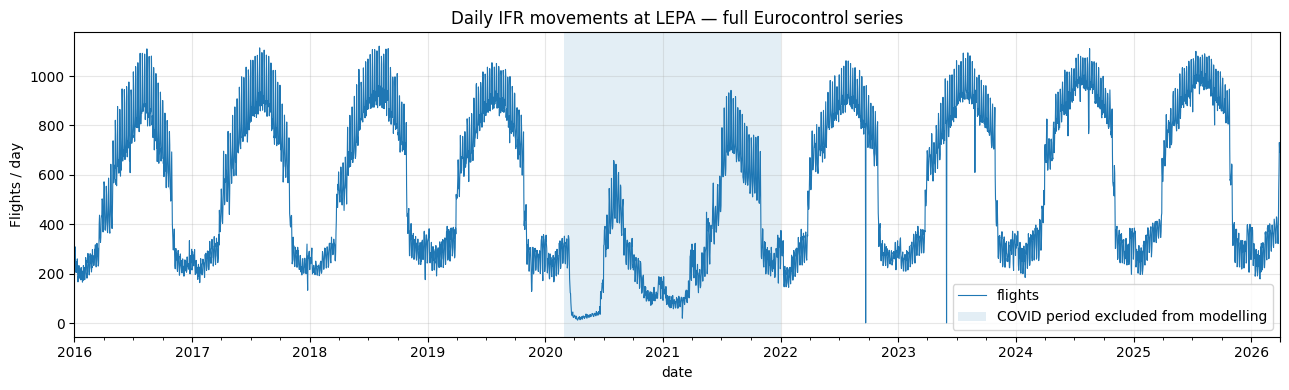

In [6]:
# Full series, with the excluded COVID period highlighted.
fig, ax = plt.subplots(figsize=(13, 4))
series_full.plot(ax=ax, linewidth=0.8)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp(COVID_CUT),
           alpha=0.12, label="COVID period excluded from modelling")
ax.set_title("Daily IFR movements at LEPA — full Eurocontrol series")
ax.set_ylabel("Flights / day")
ax.legend()
plt.tight_layout()
plt.show()

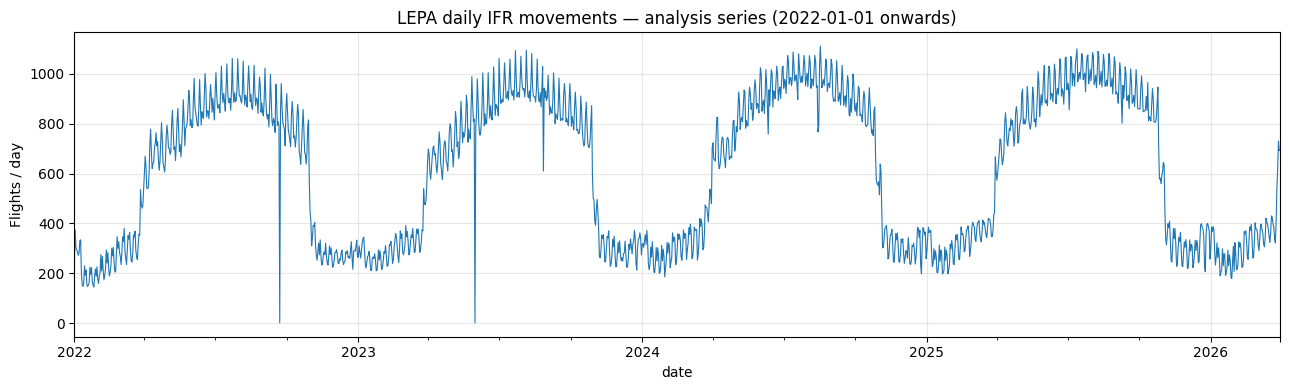

In [7]:
# Modern series used for modelling.
fig, ax = plt.subplots(figsize=(13, 4))
series.plot(ax=ax, linewidth=0.8)
ax.set_title(f"LEPA daily IFR movements — analysis series ({series.index.min().date()} onwards)")
ax.set_ylabel("Flights / day")
plt.tight_layout()
plt.show()

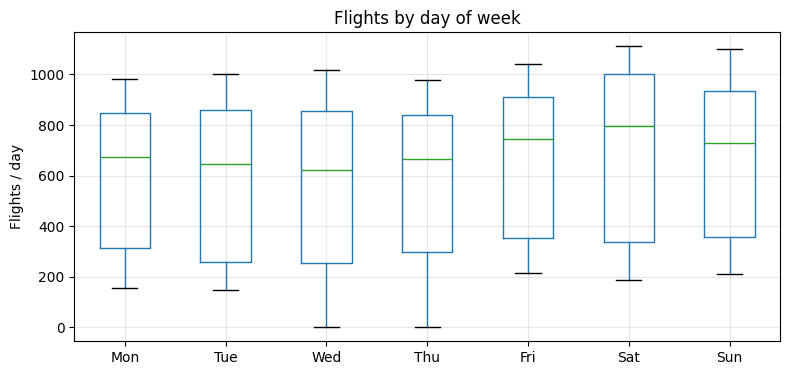

In [8]:
# Weekly seasonality: boxplot by day of week.
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df_dow = series.to_frame("flights").assign(dow=series.index.dayofweek)

fig, ax = plt.subplots(figsize=(8, 4))
df_dow.boxplot(column="flights", by="dow", ax=ax)
ax.set_xticklabels(DAY_NAMES)
ax.set_title("Flights by day of week")
ax.set_xlabel("")
ax.set_ylabel("Flights / day")
plt.suptitle("")
plt.tight_layout()
plt.show()

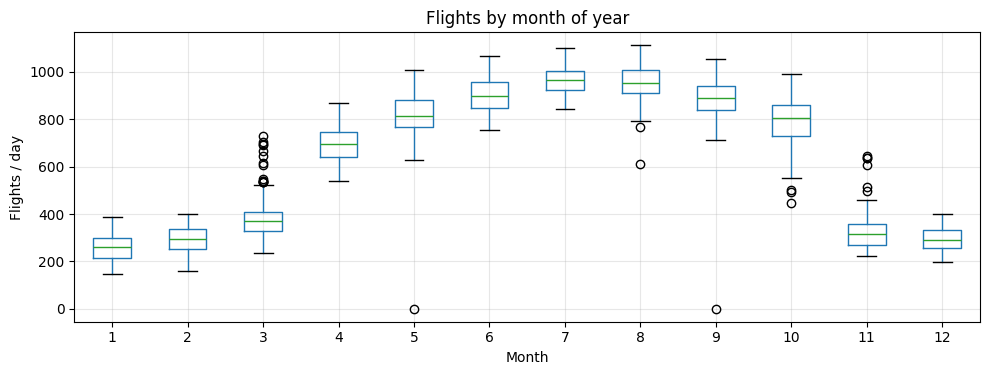

In [9]:
# Annual seasonality: boxplot by month.
df_month = series.to_frame("flights").assign(month=series.index.month)
fig, ax = plt.subplots(figsize=(10, 4))
df_month.boxplot(column="flights", by="month", ax=ax)
ax.set_title("Flights by month of year")
ax.set_xlabel("Month")
ax.set_ylabel("Flights / day")
plt.suptitle("")
plt.tight_layout()
plt.show()

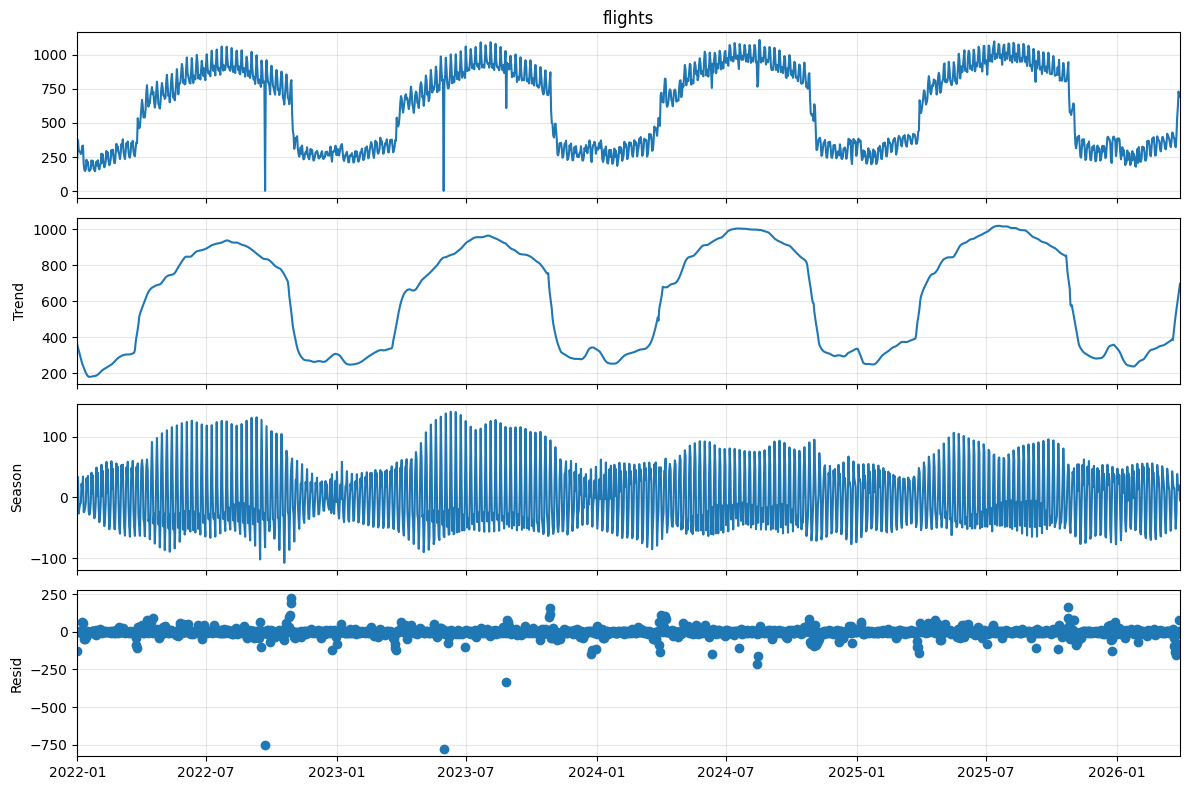

In [10]:
# STL decomposition with weekly seasonality.
stl = STL(series, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

### 2.1 Stationarity tests and ACF/PACF

ADF and KPSS are used together:

- **ADF null hypothesis:** the series has a unit root.
- **KPSS null hypothesis:** the series is stationary.

The lag-7 differenced series is also tested because the ACF/PACF after weekly differencing is useful for ARMA/ARIMA/SARIMA order selection.

In [11]:
def report_adf(x, name=""):
    stat, p, *_ = adfuller(pd.Series(x).dropna(), autolag="AIC")
    verdict = "reject unit root (stationary-ish)" if p < 0.05 else "cannot reject unit root"
    print(f"ADF  on {name:20s}  stat={stat:8.3f}  p={p:.4f}   -> {verdict}")
    return stat, p

def report_kpss(x, name=""):
    stat, p, *_ = kpss(pd.Series(x).dropna(), regression="c", nlags="auto")
    verdict = "reject stationarity" if p < 0.05 else "cannot reject stationarity"
    print(f"KPSS on {name:20s}  stat={stat:8.3f}  p={p:.4f}   -> {verdict}")
    return stat, p

print("Raw series")
adf_raw = report_adf(series, "raw")
kpss_raw = report_kpss(series, "raw")
print()

series_d7 = series.diff(7)
print("Lag-7 differenced series")
adf_d7 = report_adf(series_d7, "diff_7")
kpss_d7 = report_kpss(series_d7, "diff_7")

Raw series
ADF  on raw                   stat=  -3.148  p=0.0232   -> reject unit root (stationary-ish)
KPSS on raw                   stat=   0.131  p=0.1000   -> cannot reject stationarity

Lag-7 differenced series
ADF  on diff_7                stat=  -5.128  p=0.0000   -> reject unit root (stationary-ish)
KPSS on diff_7                stat=   0.083  p=0.1000   -> cannot reject stationarity


C:\Users\xabier.villa\AppData\Local\Temp\ipykernel_5156\2209808640.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(pd.Series(x).dropna(), regression="c", nlags="auto")
C:\Users\xabier.villa\AppData\Local\Temp\ipykernel_5156\2209808640.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(pd.Series(x).dropna(), regression="c", nlags="auto")


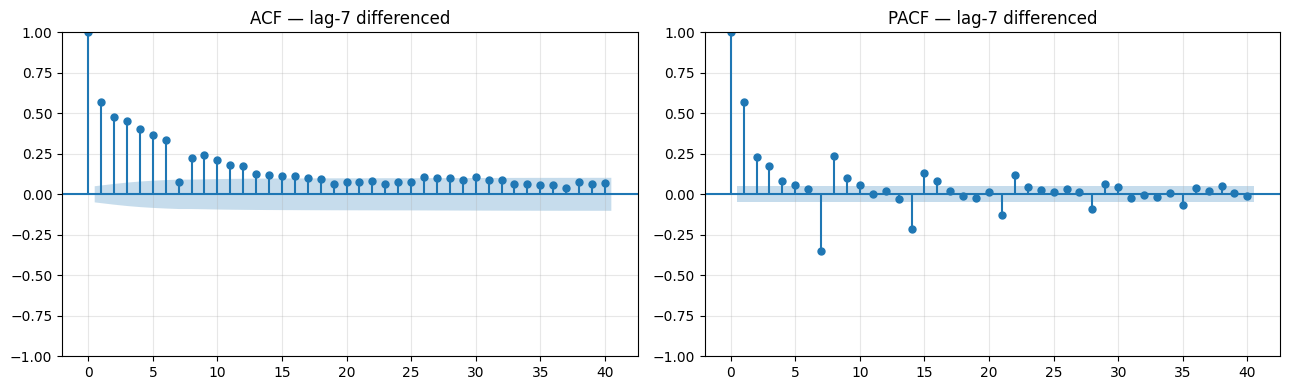

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series_d7.dropna(), lags=40, ax=axes[0])
plot_pacf(series_d7.dropna(), lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF — lag-7 differenced")
axes[1].set_title("PACF — lag-7 differenced")
plt.tight_layout()
plt.show()

## 3. Evaluation Harness

All models are evaluated using the same rolling-origin protocol:

- Forecast horizon: **14 days**
- Number of test windows: **12**
- Step: **14 days**, non-overlapping
- Main metric: **MAE** in flights/day
- Secondary metric: **RMSE** in flights/day

MAE is the main comparison metric because it is directly interpretable: an MAE of 20 means the model is wrong by about 20 flights per day on average.

In [13]:
HORIZON = 14
N_WINDOWS = 12
STEP = HORIZON

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    assert mask.all(), "NaN or infinite value found during MAE calculation."
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    assert mask.all(), "NaN or infinite value found during RMSE calculation."
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def get_windows(series, horizon=HORIZON, n_windows=N_WINDOWS, step=STEP):
    test_size = n_windows * step
    train_end = len(series) - test_size
    assert train_end > 365, "Not enough history before the test windows."
    for i in range(n_windows):
        cutoff = train_end + i * step
        train = series.iloc[:cutoff]
        actual = series.iloc[cutoff:cutoff + horizon]
        assert len(actual) == horizon
        assert train.notna().all() and actual.notna().all()
        yield train, actual

def evaluate(forecast_fn, series=series, horizon=HORIZON,
             n_windows=N_WINDOWS, step=STEP, name=""):
    maes, rmses = [], []
    for w, (train, actual) in enumerate(get_windows(series, horizon, n_windows, step), start=1):
        preds = np.asarray(forecast_fn(train, horizon), dtype=float)
        assert len(preds) == horizon, f"{name}: returned {len(preds)} predictions, expected {horizon}"
        if not np.isfinite(preds).all():
            raise ValueError(f"{name}: forecast contains NaN or infinite values in window {w}.")
        maes.append(mae(actual.values, preds))
        rmses.append(rmse(actual.values, preds))
    return {
        "model": name,
        "mae": float(np.mean(maes)),
        "rmse": float(np.mean(rmses)),
        "per_window_mae": maes,
    }

results = []
def add_result(r):
    results.append(r)
    return r

windows = list(get_windows(series))
print(f"Number of test windows: {len(windows)}")
print(f"First window: train ends {windows[0][0].index[-1].date()}, "
      f"forecast {windows[0][1].index[0].date()} -> {windows[0][1].index[-1].date()}")
print(f"Last window:  train ends {windows[-1][0].index[-1].date()}, "
      f"forecast {windows[-1][1].index[0].date()} -> {windows[-1][1].index[-1].date()}")

Number of test windows: 12
First window: train ends 2025-10-14, forecast 2025-10-15 -> 2025-10-28
Last window:  train ends 2026-03-17, forecast 2026-03-18 -> 2026-03-31


## 4. Baselines

We use three baselines:

1. **Last value**: repeat the most recent observed day.
2. **Mean**: repeat the historical mean of the training period.
3. **Seasonal naive lag-7**: repeat the last observed week.

The seasonal naive baseline is the most important reference because the series has strong weekly structure.

In [14]:
def baseline_last(train, h):
    return np.repeat(train.iloc[-1], h)

def baseline_mean(train, h):
    return np.repeat(train.mean(), h)

def baseline_seasonal_naive_7(train, h):
    last_week = train.iloc[-7:].values
    reps = int(np.ceil(h / 7))
    return np.tile(last_week, reps)[:h]

for name, fn in [
    ("Baseline — last value", baseline_last),
    ("Baseline — mean", baseline_mean),
    ("Baseline — seasonal naive (7)", baseline_seasonal_naive_7),
]:
    r = evaluate(fn, name=name)
    add_result(r)
    print(f"{r['model']:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}")

Baseline — last value                     MAE=   79.58   RMSE=   98.42
Baseline — mean                           MAE=  290.75   RMSE=  299.86
Baseline — seasonal naive (7)             MAE=   68.75   RMSE=   85.39


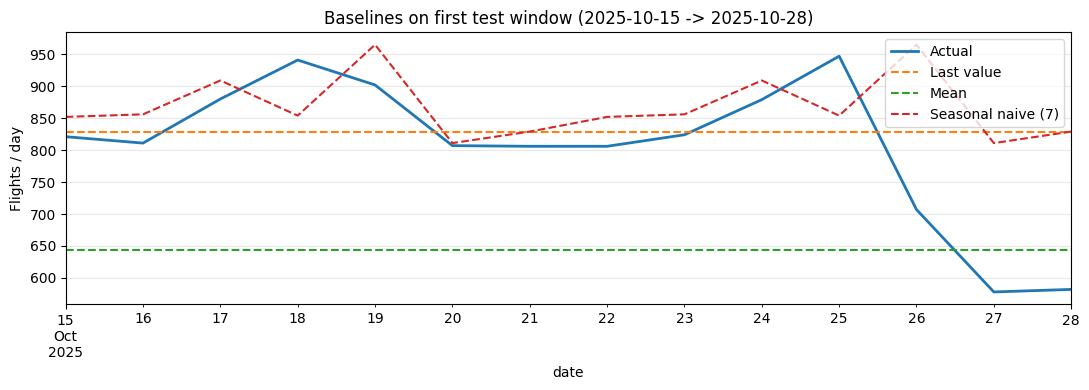

In [15]:
# Visual check on the first test window.
train_w, actual_w = windows[0]
fig, ax = plt.subplots(figsize=(11, 4))
actual_w.plot(ax=ax, label="Actual", linewidth=2)
ax.plot(actual_w.index, baseline_last(train_w, HORIZON), label="Last value", linestyle="--")
ax.plot(actual_w.index, baseline_mean(train_w, HORIZON), label="Mean", linestyle="--")
ax.plot(actual_w.index, baseline_seasonal_naive_7(train_w, HORIZON), label="Seasonal naive (7)", linestyle="--")
ax.set_title(f"Baselines on first test window ({actual_w.index[0].date()} -> {actual_w.index[-1].date()})")
ax.set_ylabel("Flights / day")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Section 2 — ARMA

ARMA is theoretically appropriate only for a stationary series without an integrated component. In our modern analysis window, the ADF and KPSS tests do not provide strong evidence against stationarity: ADF rejects the unit-root null and KPSS does not reject the stationarity null. However, the time-series plot, STL decomposition and ACF/PACF still show clear weekly and annual structure. For this reason, ARMA is included as a classical stationary benchmark, but it is not expected to be the best-performing model for this dataset.

We evaluate two small ARMA configurations:

- ARMA(1,1), implemented as SARIMAX order `(1,0,1)`
- ARMA(2,2), implemented as SARIMAX order `(2,0,2)`

In [16]:
def sarimax_forecast(train, h, order, seasonal_order=(0, 0, 0, 0), trend="c", maxiter=100):
    model = SARIMAX(
        train.astype(float).values,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False, maxiter=maxiter)
    pred = fitted.forecast(h)
    return np.asarray(pred, dtype=float)

def make_sarimax_fn(order, seasonal_order=(0, 0, 0, 0), trend="c"):
    def fn(train, h):
        return sarimax_forecast(train, h, order=order, seasonal_order=seasonal_order, trend=trend)
    return fn

arma_configs = {
    "ARMA(1,1)": (1, 0, 1),
    "ARMA(2,2)": (2, 0, 2),
}

for name, order in arma_configs.items():
    print(f"Evaluating {name}...")
    t0 = time()
    r = evaluate(make_sarimax_fn(order), name=name)
    add_result(r)
    print(f"{name:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}   [{time()-t0:.1f}s]")

Evaluating ARMA(1,1)...
ARMA(1,1)                                 MAE=   75.32   RMSE=   94.03   [0.9s]
Evaluating ARMA(2,2)...
ARMA(2,2)                                 MAE=   79.30   RMSE=   97.25   [8.6s]


## 6. Section 3 — ARIMA

Although the raw modern series is not clearly non-stationary, ARIMA is included because the rubric explicitly requires it. We test at least two different combinations of `p` and `q`:

- ARIMA(1,1,1)
- ARIMA(2,1,2)

We also include a naive seasonal ARIMA approach: manually apply a lag-7 seasonal difference, fit a non-seasonal ARIMA to the differenced series and reconstruct the forecast recursively.

In [17]:
arima_configs = {
    "ARIMA(1,1,1)": (1, 1, 1),
    "ARIMA(2,1,2)": (2, 1, 2),
}

for name, order in arima_configs.items():
    print(f"Evaluating {name}...")
    t0 = time()
    r = evaluate(make_sarimax_fn(order, trend="c"), name=name)
    add_result(r)
    print(f"{name:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}   [{time()-t0:.1f}s]")

Evaluating ARIMA(1,1,1)...
ARIMA(1,1,1)                              MAE=   79.22   RMSE=   97.05   [3.9s]
Evaluating ARIMA(2,1,2)...
ARIMA(2,1,2)                              MAE=   78.31   RMSE=   95.83   [7.9s]


In [18]:
def seasonal_diff_arima_forecast(train, h, order=(1, 0, 1), season_lag=7):
    # Fit ARIMA to y_t - y_(t-7).
    diffed = train.diff(season_lag).dropna()
    diff_pred = sarimax_forecast(diffed, h, order=order, seasonal_order=(0, 0, 0, 0), trend="c")

    # Reconstruct y forecasts recursively: y_hat[t] = y[t-7] + diff_hat[t].
    history = list(train.astype(float).values)
    preds = []
    for delta in diff_pred:
        y_hat = history[-season_lag] + delta
        preds.append(y_hat)
        history.append(y_hat)
    return np.asarray(preds)

print("Evaluating ARIMA with manual lag-7 seasonal differencing...")
t0 = time()
r = evaluate(
    lambda train, h: seasonal_diff_arima_forecast(train, h, order=(1, 0, 1), season_lag=7),
    name="ARIMA + manual seasonal diff(7)"
)
add_result(r)
print(f"{r['model']:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}   [{time()-t0:.1f}s]")

Evaluating ARIMA with manual lag-7 seasonal differencing...
ARIMA + manual seasonal diff(7)           MAE=   57.19   RMSE=   73.57   [2.2s]


### 6.1 Residual diagnostics for the best classical model

The best classical model is the manual lag-7 seasonal ARIMA. As requested in the correction, we inspect its residuals and residual ACF. If residuals behave like white noise, the model is reasonably specified; if the residual ACF still shows spikes at weekly multiples such as 14 or 21, the model is still missing part of the repeated weekly structure.

In [ ]:
# Residual diagnostics for the best classical model: ARIMA + manual seasonal diff(7).
# We fit the model on the initial training period used before the first rolling window.
cutoff_diag = len(series) - N_WINDOWS * STEP
train_diag = series.iloc[:cutoff_diag].astype(float)
diag_diffed = train_diag.diff(7).dropna()

fit_diag = SARIMAX(
    diag_diffed.values,
    order=(1, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=120)

residuals_manual_arima = pd.Series(fit_diag.resid, index=diag_diffed.index, name="residual")
# Remove the earliest residuals where state-space initialisation can dominate the pattern.
residuals_manual_arima = residuals_manual_arima.iloc[14:].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
residuals_manual_arima.plot(ax=axes[0], linewidth=0.8)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Manual seasonal ARIMA residuals")
axes[0].set_ylabel("Residuals on lag-7 differenced series")

plot_acf(residuals_manual_arima, lags=42, ax=axes[1])
axes[1].set_title("ACF of residuals")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_manual_seasonal_arima_residuals_acf.png"), dpi=180, bbox_inches="tight")
plt.show()

print("Residual diagnostic note:")
print("Check whether the ACF has significant spikes at weekly multiples such as 7, 14, 21, 28 or 35.")
print("Remaining seasonal spikes mean that the classical model still leaves temporal structure unexplained.")

## 7. Section 4 — SARIMA

SARIMA extends ARIMA with an explicit seasonal component. The weekly pattern is the clearest and most operationally relevant short-cycle seasonality, so we use `m=7`.

A full annual SARIMA with `m=365` would be computationally expensive and unstable for this dataset, especially in rolling evaluation. The annual tourist cycle is therefore handled indirectly through the recent training history, while the model explicitly represents weekly seasonality.

In [19]:
sarima_configs = {
    "SARIMA(1,0,1)(1,1,1,7)": ((1, 0, 1), (1, 1, 1, 7)),
    "SARIMA(2,0,1)(1,1,1,7)": ((2, 0, 1), (1, 1, 1, 7)),
}

for name, (order, seasonal_order) in sarima_configs.items():
    print(f"Evaluating {name}...")
    t0 = time()
    r = evaluate(make_sarimax_fn(order, seasonal_order=seasonal_order, trend="c"), name=name)
    add_result(r)
    print(f"{name:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}   [{time()-t0:.1f}s]")

Evaluating SARIMA(1,0,1)(1,1,1,7)...
SARIMA(1,0,1)(1,1,1,7)                    MAE=   61.61   RMSE=   78.89   [11.2s]
Evaluating SARIMA(2,0,1)(1,1,1,7)...
SARIMA(2,0,1)(1,1,1,7)                    MAE=   62.46   RMSE=   79.74   [18.3s]


## 8. Section 5 — AutoARIMA

We run AutoARIMA twice:

1. **Without seasonality** (`seasonal=False`)
2. **With weekly seasonality** (`seasonal=True`, `m=7`)

For efficiency, the order search is performed once on the training data available before the first rolling window. The selected order is then refitted in each rolling window.

In [20]:
def try_import_pmdarima():
    try:
        import pmdarima as pm
        return pm
    except Exception as first_error:
        print("pmdarima is not available. Trying to install it...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pmdarima"])
            import pmdarima as pm
            return pm
        except Exception as second_error:
            print("pmdarima could not be installed/imported in this environment.")
            print(f"First error:  {first_error}")
            print(f"Second error: {second_error}")
            return None

def fallback_order_search(y, seasonal=False, m=7):
    # Lightweight AIC grid search used only if pmdarima is unavailable.
    best_aic = np.inf
    best_order = None
    best_seasonal = (0, 0, 0, 0)

    d_values = [0, 1]
    p_values = [0, 1, 2]
    q_values = [0, 1, 2]

    if seasonal:
        seasonal_candidates = [(P, 1, Q, m) for P in [0, 1] for Q in [0, 1]]
    else:
        seasonal_candidates = [(0, 0, 0, 0)]

    for p, d, q in product(p_values, d_values, q_values):
        if p == 0 and q == 0:
            continue
        for seas in seasonal_candidates:
            try:
                fit = SARIMAX(
                    y,
                    order=(p, d, q),
                    seasonal_order=seas,
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=80)
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_order = (p, d, q)
                    best_seasonal = seas
            except Exception:
                continue

    assert best_order is not None, "Fallback AutoARIMA grid search failed."
    return best_order, best_seasonal, best_aic

CUTOFF = len(series) - N_WINDOWS * STEP
initial_train = series.iloc[:CUTOFF].astype(float).values

pm = try_import_pmdarima()

if pm is not None:
    print("AutoARIMA — non-seasonal order search...")
    t0 = time()
    fit_ns = pm.auto_arima(
        initial_train,
        seasonal=False,
        stepwise=True,
        information_criterion="aic",
        suppress_warnings=True,
        error_action="ignore",
        random_state=SEED,
    )
    order_ns = fit_ns.order
    seasonal_ns = (0, 0, 0, 0)
    print(f"  Best non-seasonal order = {order_ns} [{time()-t0:.1f}s]")
    print(fit_ns.summary())

    print("\nAutoARIMA — seasonal order search (m=7)...")
    t0 = time()
    fit_s = pm.auto_arima(
        initial_train,
        seasonal=True,
        m=7,
        D=1,
        stepwise=True,
        information_criterion="aic",
        suppress_warnings=True,
        error_action="ignore",
        random_state=SEED,
    )
    order_s = fit_s.order
    seasonal_s = fit_s.seasonal_order
    print(f"  Best order={order_s}, seasonal_order={seasonal_s} [{time()-t0:.1f}s]")
    print(fit_s.summary())
else:
    print("Using fallback AIC grid search as AutoARIMA substitute.")
    t0 = time()
    order_ns, seasonal_ns, aic_ns = fallback_order_search(initial_train, seasonal=False)
    print(f"  Fallback non-seasonal order={order_ns}, AIC={aic_ns:.2f} [{time()-t0:.1f}s]")

    t0 = time()
    order_s, seasonal_s, aic_s = fallback_order_search(initial_train, seasonal=True, m=7)
    print(f"  Fallback seasonal order={order_s}, seasonal_order={seasonal_s}, AIC={aic_s:.2f} [{time()-t0:.1f}s]")

AutoARIMA — non-seasonal order search...
  Best non-seasonal order = (5, 1, 5) [17.3s]
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1383
Model:               SARIMAX(5, 1, 5)   Log Likelihood               -7460.267
Date:                Wed, 20 May 2026   AIC                          14942.533
Time:                        18:11:46   BIC                          15000.077
Sample:                             0   HQIC                         14964.058
                               - 1383                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7752      0.056     13.813      0.000       0.665       0.885
ar.L2         -1.4067      0.048    -29.323 

Evaluating AutoARIMA non-seasonal fixed order...


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

AutoARIMA non-seasonal (5, 1, 5)          MAE=   60.48   RMSE=   78.15   [54.9s]

Evaluating AutoARIMA seasonal fixed order...
AutoARIMA seasonal (3, 0, 2)x(0, 1, 1, 7)  MAE=   58.08   RMSE=   74.03   [34.5s]


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


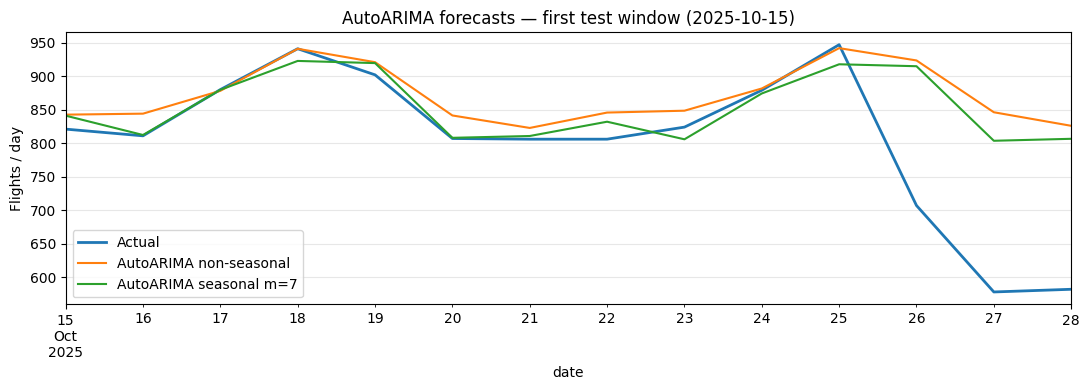

In [21]:
print("Evaluating AutoARIMA non-seasonal fixed order...")
t0 = time()
r = evaluate(
    make_sarimax_fn(order_ns, seasonal_order=seasonal_ns, trend="c"),
    name=f"AutoARIMA non-seasonal {order_ns}"
)
add_result(r)
print(f"{r['model']:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}   [{time()-t0:.1f}s]")

print("\nEvaluating AutoARIMA seasonal fixed order...")
t0 = time()
r = evaluate(
    make_sarimax_fn(order_s, seasonal_order=seasonal_s, trend="c"),
    name=f"AutoARIMA seasonal {order_s}x{seasonal_s}"
)
add_result(r)
print(f"{r['model']:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}   [{time()-t0:.1f}s]")

# Visual comparison on the first test window.
train_w, actual_w = windows[0]
fig, ax = plt.subplots(figsize=(11, 4))
actual_w.plot(ax=ax, linewidth=2, label="Actual")
ax.plot(actual_w.index, sarimax_forecast(train_w, HORIZON, order_ns, seasonal_ns), label="AutoARIMA non-seasonal")
ax.plot(actual_w.index, sarimax_forecast(train_w, HORIZON, order_s, seasonal_s), label="AutoARIMA seasonal m=7")
ax.set_title(f"AutoARIMA forecasts — first test window ({actual_w.index[0].date()})")
ax.set_ylabel("Flights / day")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Section 6 — Transformer-based Architecture

We implement an encoder-only Transformer directly in PyTorch.

| Hyperparameter | Value |
|---|---:|
| Lookback window (`INPUT_LEN`) | 90 days |
| Forecast horizon | 14 days |
| `d_model` | 64 |
| Attention heads | 4 |
| Encoder layers | 2 |
| Feedforward dimension | 128 |
| Positional encoding | Learned embedding |
| Sequence pooling | Global mean pooling |

The model is trained once on the data before the first test window. At evaluation time, the trained weights are reused and the 90-day context window slides forward.

Training on: cpu
Epoch   1/80 — train MSE (normalised) = 0.6589
Epoch  20/80 — train MSE (normalised) = 0.0469
Epoch  40/80 — train MSE (normalised) = 0.0388
Epoch  60/80 — train MSE (normalised) = 0.0310
Epoch  80/80 — train MSE (normalised) = 0.0285


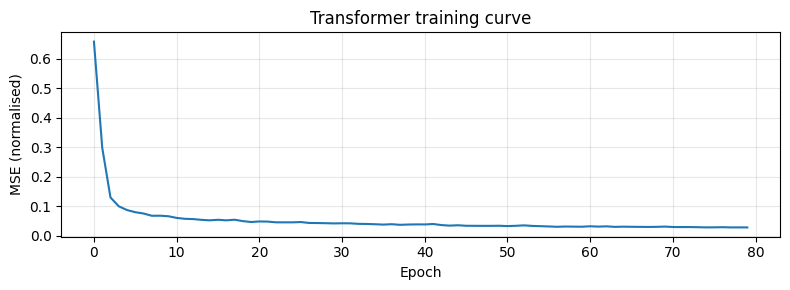

In [22]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch"])
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_LEN = 90
N_EPOCHS = 80
LR = 1e-3
BATCH_SIZE = 64

print(f"Training on: {DEVICE}")

class TSTransformer(nn.Module):
    # Encoder-only transformer: INPUT_LEN scalar values -> HORIZON forecasts.

    def __init__(self, input_len=INPUT_LEN, output_len=HORIZON,
                 d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_len = input_len
        self.input_proj = nn.Linear(1, d_model)
        self.pos_enc = nn.Embedding(input_len, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, output_len)

    def forward(self, x):
        h = self.input_proj(x.unsqueeze(-1))
        positions = torch.arange(self.input_len, device=x.device)
        h = h + self.pos_enc(positions)
        h = self.encoder(h)
        return self.head(h.mean(dim=1))

class SlidingWindowDS(Dataset):
    def __init__(self, values, input_len, output_len):
        self.v = torch.FloatTensor(values)
        self.input_len = input_len
        self.output_len = output_len

    def __len__(self):
        return len(self.v) - self.input_len - self.output_len + 1

    def __getitem__(self, i):
        return (
            self.v[i : i + self.input_len],
            self.v[i + self.input_len : i + self.input_len + self.output_len],
        )

cutoff = len(series) - N_WINDOWS * STEP
train_vals = series.iloc[:cutoff].values.astype(float)
tr_mean = train_vals.mean()
tr_std = train_vals.std()
assert tr_std > 0

train_n = (train_vals - tr_mean) / tr_std
dataset_tf = SlidingWindowDS(train_n, INPUT_LEN, HORIZON)

loader = DataLoader(
    dataset_tf,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

model_tf = TSTransformer().to(DEVICE)
optimizer = torch.optim.Adam(model_tf.parameters(), lr=LR)
criterion = nn.MSELoss()

losses = []
for epoch in range(1, N_EPOCHS + 1):
    model_tf.train()
    ep_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_tf(xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item() * len(xb)

    losses.append(ep_loss / len(dataset_tf))
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} — train MSE (normalised) = {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses)
ax.set(xlabel="Epoch", ylabel="MSE (normalised)", title="Transformer training curve")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_transformer_training_curve.png"), dpi=180, bbox_inches="tight")
plt.show()

Transformer encoder (90d window)          MAE=   37.65   RMSE=   47.43


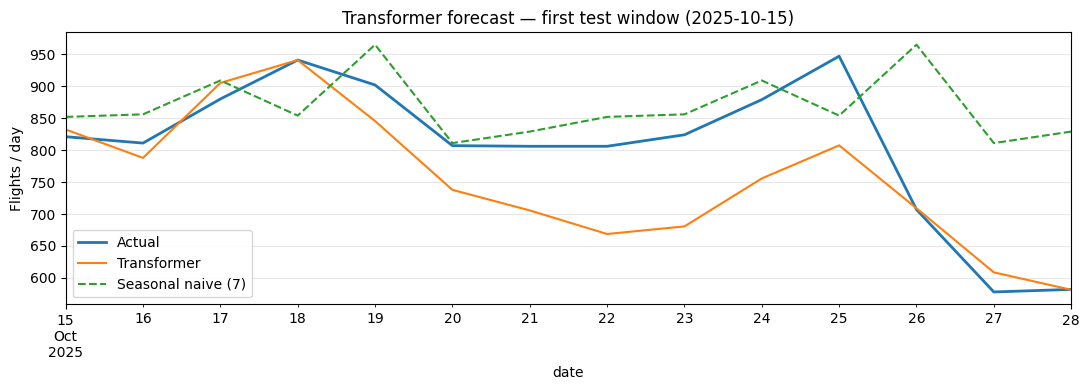

In [23]:
def transformer_fn(train, h):
    assert h == HORIZON, "The Transformer head was trained for the fixed HORIZON."
    model_tf.eval()
    vals = train.values.astype(float)
    x = torch.FloatTensor((vals[-INPUT_LEN:] - tr_mean) / tr_std).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_n = model_tf(x).squeeze().cpu().numpy()
    return pred_n * tr_std + tr_mean

r = evaluate(transformer_fn, name="Transformer encoder (90d window)")
add_result(r)
print(f"{r['model']:40s}  MAE={r['mae']:8.2f}   RMSE={r['rmse']:8.2f}")

train_w, actual_w = windows[0]
fig, ax = plt.subplots(figsize=(11, 4))
actual_w.plot(ax=ax, linewidth=2, label="Actual")
ax.plot(actual_w.index, transformer_fn(train_w, HORIZON), label="Transformer")
ax.plot(actual_w.index, baseline_seasonal_naive_7(train_w, HORIZON),
        label="Seasonal naive (7)", linestyle="--")
ax.set_title(f"Transformer forecast — first test window ({actual_w.index[0].date()})")
ax.set_ylabel("Flights / day")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Section 7 — Results Discussion

All methods are compared using the same metric and rolling windows. The table below is the main evidence for the final discussion.

In [24]:
df_res = (
    pd.DataFrame(results)[["model", "mae", "rmse"]]
    .sort_values("mae")
    .reset_index(drop=True)
)

df_res.index += 1
df_res.columns = ["Model", "MAE (flights/day)", "RMSE (flights/day)"]
df_res["MAE (flights/day)"] = df_res["MAE (flights/day)"].round(2)
df_res["RMSE (flights/day)"] = df_res["RMSE (flights/day)"].round(2)

print("=" * 80)
print(df_res.to_string())
print("=" * 80)

# Save table for easy insertion into the written document.
df_res.to_csv("D2_2_results_table.csv", index=True)
print("Saved results table to D2_2_results_table.csv")

try:
    display(
        df_res.style
        .highlight_min(subset=["MAE (flights/day)"], color="lightgreen")
        .highlight_max(subset=["MAE (flights/day)"], color="#ffe0e0")
        .format({"MAE (flights/day)": "{:.2f}", "RMSE (flights/day)": "{:.2f}"})
    )
except Exception:
    pass

                                        Model  MAE (flights/day)  RMSE (flights/day)
1            Transformer encoder (90d window)              37.65               47.43
2             ARIMA + manual seasonal diff(7)              57.19               73.57
3   AutoARIMA seasonal (3, 0, 2)x(0, 1, 1, 7)              58.08               74.03
4            AutoARIMA non-seasonal (5, 1, 5)              60.48               78.15
5                      SARIMA(1,0,1)(1,1,1,7)              61.61               78.89
6                      SARIMA(2,0,1)(1,1,1,7)              62.46               79.74
7               Baseline — seasonal naive (7)              68.75               85.39
8                                   ARMA(1,1)              75.32               94.03
9                                ARIMA(2,1,2)              78.31               95.83
10                               ARIMA(1,1,1)              79.22               97.05
11                                  ARMA(2,2)              79.30 

,Model,MAE (flights/day),RMSE (flights/day)
1,Transformer encoder (90d window),37.65,47.43
2,ARIMA + manual seasonal diff(7),57.19,73.57
3,"AutoARIMA seasonal (3, 0, 2)x(0, 1, 1, 7)",58.08,74.03
4,"AutoARIMA non-seasonal (5, 1, 5)",60.48,78.15
5,"SARIMA(1,0,1)(1,1,1,7)",61.61,78.89
6,"SARIMA(2,0,1)(1,1,1,7)",62.46,79.74
7,Baseline — seasonal naive (7),68.75,85.39
8,"ARMA(1,1)",75.32,94.03
9,"ARIMA(2,1,2)",78.31,95.83
10,"ARIMA(1,1,1)",79.22,97.05


### 10.1 Forecast plots requested after professor feedback

The following diagnostics were added after the professor's correction. They are intentionally few and targeted: one representative forecast window, one per-window MAE trajectory, and one day-of-horizon error distribution. Together they show not only which model wins on average, but also how and when it wins.

In [ ]:
# Helper: get model results by exact name.
def get_result(model_name):
    matches = [r for r in results if r["model"] == model_name]
    if not matches:
        raise ValueError(f"Model result not found: {model_name}")
    return matches[0]

# Representative window: choose the rolling test window with the highest observed traffic value.
# This usually corresponds to a high-season period and is visually more informative than a quiet winter window.
representative_idx = int(np.argmax([actual.max() for _, actual in windows]))
train_rep, actual_rep = windows[representative_idx]

pred_seasonal_naive = baseline_seasonal_naive_7(train_rep, HORIZON)
pred_manual_seasonal_arima = seasonal_diff_arima_forecast(train_rep, HORIZON, order=(1, 0, 1), season_lag=7)
pred_transformer = transformer_fn(train_rep, HORIZON)

fig, ax = plt.subplots(figsize=(12, 4))
actual_rep.plot(ax=ax, label="Actual", color="black", linewidth=2.5)
ax.plot(actual_rep.index, pred_seasonal_naive, label="Seasonal naive (reference)", linestyle="--", linewidth=1.8)
ax.plot(actual_rep.index, pred_manual_seasonal_arima, label="Best classical: manual seasonal ARIMA", linestyle="-.", linewidth=1.8)
ax.plot(actual_rep.index, pred_transformer, label="Transformer", linewidth=2.0)
ax.set_title(
    f"Forecast vs actual — representative high-traffic window "
    f"{representative_idx + 1} ({actual_rep.index[0].date()} to {actual_rep.index[-1].date()})"
)
ax.set_ylabel("Flights / day")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_forecast_vs_actual_representative_window.png"), dpi=180, bbox_inches="tight")
plt.show()

print(f"Representative window selected: {representative_idx + 1}")
print(f"Window dates: {actual_rep.index[0].date()} -> {actual_rep.index[-1].date()}")
print(f"Actual maximum flights/day in this window: {actual_rep.max():.0f}")

In [ ]:
# Per-window MAE trajectory for the three most important comparison lines.
focus_models = [
    "Baseline — seasonal naive (7)",
    "ARIMA + manual seasonal diff(7)",
    "Transformer encoder (90d window)",
]

fig, ax = plt.subplots(figsize=(11, 4))
for name in focus_models:
    r = get_result(name)
    ax.plot(range(1, N_WINDOWS + 1), r["per_window_mae"], marker="o", linewidth=2, label=name)
ax.set_xlabel("Test window (chronological)")
ax.set_ylabel("MAE (flights / day)")
ax.set_title("Per-window MAE trajectory — reference vs best classical vs Transformer")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_per_window_mae_focused.png"), dpi=180, bbox_inches="tight")
plt.show()

print("Average MAE over the 12 windows:")
for name in focus_models:
    r = get_result(name)
    print(f"{name:40s} MAE={r['mae']:.2f}")

In [ ]:
# Optional but useful: forecast-error distribution by day of horizon.
# We compare the Transformer with the seasonal naive reference.
rows = []
for w, (train, actual) in enumerate(windows, start=1):
    actual_values = actual.values.astype(float)
    preds_by_model = {
        "Seasonal naive": baseline_seasonal_naive_7(train, HORIZON),
        "Transformer": transformer_fn(train, HORIZON),
    }
    for model_name, preds in preds_by_model.items():
        abs_errors = np.abs(actual_values - np.asarray(preds, dtype=float))
        for h_day, err in enumerate(abs_errors, start=1):
            rows.append({"window": w, "horizon_day": h_day, "model": model_name, "abs_error": err})

horizon_errors = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 4))
positions_sn = np.arange(1, HORIZON + 1) - 0.18
positions_tf = np.arange(1, HORIZON + 1) + 0.18
sn_data = [horizon_errors[(horizon_errors["model"] == "Seasonal naive") & (horizon_errors["horizon_day"] == h)]["abs_error"].values for h in range(1, HORIZON + 1)]
tf_data = [horizon_errors[(horizon_errors["model"] == "Transformer") & (horizon_errors["horizon_day"] == h)]["abs_error"].values for h in range(1, HORIZON + 1)]

bp1 = ax.boxplot(sn_data, positions=positions_sn, widths=0.28, patch_artist=True, showfliers=False)
bp2 = ax.boxplot(tf_data, positions=positions_tf, widths=0.28, patch_artist=True, showfliers=False)

# Use neutral fills and a legend based on the first box of each group.
for patch in bp1["boxes"]:
    patch.set_alpha(0.35)
for patch in bp2["boxes"]:
    patch.set_alpha(0.75)

ax.set_xticks(range(1, HORIZON + 1))
ax.set_xlabel("Forecast horizon day")
ax.set_ylabel("Absolute error (flights / day)")
ax.set_title("Forecast error distribution by day of horizon")
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Seasonal naive", "Transformer"], loc="upper left")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_error_distribution_by_horizon.png"), dpi=180, bbox_inches="tight")
plt.show()

try:
    display(horizon_errors.groupby(["model", "horizon_day"])["abs_error"].mean().unstack(0).round(2))
except Exception:
    print(horizon_errors.groupby(["model", "horizon_day"])["abs_error"].mean().unstack(0).round(2))

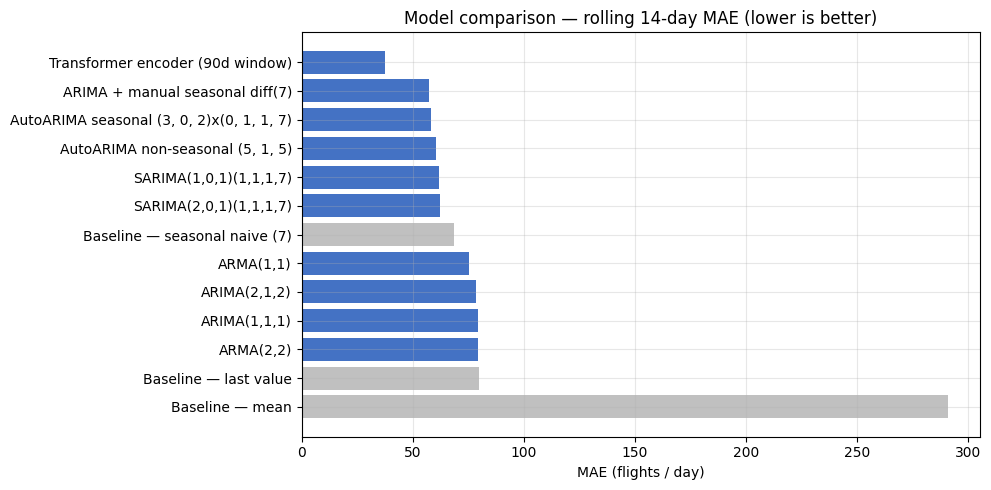

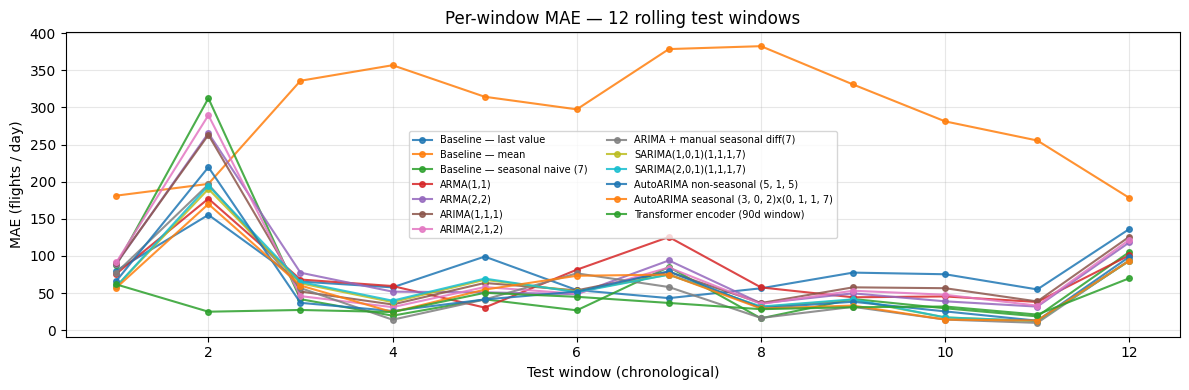

Key findings
────────────────────────────────────────────────────────────────────────────────
Best model by MAE: Transformer encoder (90d window) with MAE=37.65 flights/day.
Improvement over seasonal naive: 31.10 flights/day.
Classical seasonal models are expected to be strong because the series has a clear weekly cycle.
The Transformer is useful as the required deep-learning architecture, but its value must be judged against the seasonal naive and SARIMA/AutoARIMA baselines.
The per-window plot should be used to identify whether errors concentrate in specific operational periods.
────────────────────────────────────────────────────────────────────────────────


In [25]:
# Overall MAE bar chart.
sorted_r = sorted(results, key=lambda x: x["mae"])
bar_colors = ["#c0c0c0" if "Baseline" in r["model"] else "#4472C4" for r in sorted_r]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([r["model"] for r in sorted_r], [r["mae"] for r in sorted_r], color=bar_colors)
ax.set_xlabel("MAE (flights / day)")
ax.set_title("Model comparison — rolling 14-day MAE (lower is better)")
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_model_comparison_mae_bar.png"), dpi=180, bbox_inches="tight")
plt.show()

# Per-window MAE trajectory.
fig, ax = plt.subplots(figsize=(12, 4))
for r in results:
    ax.plot(range(1, N_WINDOWS + 1), r["per_window_mae"],
            label=r["model"], marker="o", markersize=4, alpha=0.85)
ax.set_xlabel("Test window (chronological)")
ax.set_ylabel("MAE (flights / day)")
ax.set_title("Per-window MAE — 12 rolling test windows")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_per_window_mae_all_models.png"), dpi=180, bbox_inches="tight")
plt.show()

best_model = df_res.iloc[0]["Model"]
best_mae = df_res.iloc[0]["MAE (flights/day)"]
seasonal_naive_row = df_res[df_res["Model"].str.contains("seasonal naive", case=False, regex=False)]
seasonal_naive_mae = None if seasonal_naive_row.empty else float(seasonal_naive_row.iloc[0]["MAE (flights/day)"])

print("Key findings")
print("─" * 80)
print(f"Best model by MAE: {best_model} with MAE={best_mae:.2f} flights/day.")
if seasonal_naive_mae is not None:
    improvement = seasonal_naive_mae - float(best_mae)
    print(f"Improvement over seasonal naive: {improvement:.2f} flights/day.")
print("Classical seasonal models are expected to be strong because the series has a clear weekly cycle.")
print("The Transformer is useful as the required deep-learning architecture, but its value must be judged against the seasonal naive and SARIMA/AutoARIMA baselines.")
print("The per-window plot should be used to identify whether errors concentrate in specific operational periods.")
print("─" * 80)

## 11. Section 8 — Lessons Learned

### 1. The evaluation design matters more than a single forecast plot

A single train/test split can make a model look good or bad depending on the chosen dates. Rolling-origin evaluation is more demanding because every model must generalise repeatedly across several windows. This made the final table more reliable and easier to interpret operationally.

### 2. Missing-value handling can silently corrupt the test set

The first version of the notebook produced `NaN` baseline metrics because the missing dates at the end of the Eurocontrol export were not handled safely. The corrected pipeline trims trailing unpublished dates before imputation and asserts that both the training and test windows contain only real numeric values.

### 3. Weekly seasonality is the dominant short-cycle pattern

The day-of-week boxplot, STL decomposition and lag-7 ACF/PACF show that weekly effects matter strongly. This explains why the seasonal naive lag-7 baseline is difficult to beat and why SARIMA/AutoARIMA with `m=7` are central models.

### 4. Annual seasonality exists, but `m=365` is not practical here

LEPA is a tourist airport, so the monthly boxplot shows a clear annual demand cycle. However, a full daily SARIMA with `m=365` would be computationally heavy and unstable in rolling evaluation. We therefore model the weekly cycle explicitly and leave the annual cycle to the recent training history.

### 5. Classical models remain competitive

The Transformer is included because the assignment requires a Transformer-based architecture, but the final conclusion should compare it honestly against simple baselines and SARIMA/AutoARIMA. In short-horizon daily forecasting, a well-specified classical seasonal model can be as useful as a more complex neural model.

### 6. Parameter choices must be justified

- ARMA uses `d=0` because it assumes stationarity.
- ARIMA tests multiple `(p,d,q)` combinations as required.
- SARIMA uses `m=7` because weekly seasonality is the clearest repeated pattern.
- AutoARIMA is run with and without seasonality to test whether the algorithm selects a structure consistent with the analysis.
- The Transformer uses a 90-day lookback as a compromise between enough seasonal context and manageable training cost.

### 7. Interpreting the large Transformer gain

The Transformer improvement over the seasonal naive baseline is large for daily air-traffic forecasting, so it should not be presented as magic model superiority. A plausible explanation is that the Transformer uses the last 90 days as context, allowing it to exploit recent post-COVID growth and part of the annual high-season ramp-up, while SARIMA with `m=7` explicitly models the weekly cycle but not the broader annual cycle. The added forecast-window plot and per-window MAE trajectory are therefore necessary evidence: they show whether the gain is consistent and whether the neural model tracks the weekly shape better rather than only matching the level.

### 8. Final submission checklist

Before submitting:

1. Insert the public Google Drive dataset link.
2. Run all notebook cells from top to bottom.
3. Confirm there are no `NaN` values in the results table.
4. Save the notebook with all outputs visible.
5. Copy the final results table and the most important figures into the written document.